In [44]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv", sep=";")
df.head()
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains                       

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

In [45]:
df.columns

Index(['Date', 'Service', 'Departure station', 'Arrival station',
       'Average journey time', 'Number of scheduled trains',
       'Number of cancelled trains', 'Cancellation comments',
       'Number of trains delayed at departure',
       'Average delay of late trains at departure',
       'Average delay of all trains at departure', 'Departure delay comments',
       'Number of trains delayed at arrival',
       'Average delay of late trains at arrival',
       'Average delay of all trains at arrival', 'Arrival delay comments',
       'Number of trains delayed > 15min',
       'Average delay of trains > 15min (if competing with flights)',
       'Number of trains delayed > 30min', 'Number of trains delayed > 60min',
       'Pct delay due to external causes', 'Pct delay due to infrastructure',
       'Pct delay due to traffic management', 'Pct delay due to rolling stock',
       'Pct delay due to station management and equipment reuse',
       'Pct delay due to passenger handling (

In [46]:
df = df.drop(columns=[
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments"
])

In [47]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [48]:
for col in df.columns:
    if col != "Date" and col not in ["Service", "Departure station", "Arrival station"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [49]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.dayofweek
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

In [50]:
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",year,month,weekday,is_weekend
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,36.134454,31.092437,10.924370,15.966387,NaN,0.840336,2018.0,1.0,0.0,0
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018.0,1.0,0.0,0
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018.0,1.0,0.0,0
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018.0,1.0,0.0,0
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018.0,1.0,0.0,0


In [51]:
df.to_csv("cleaned_dataset.csv", index=False)

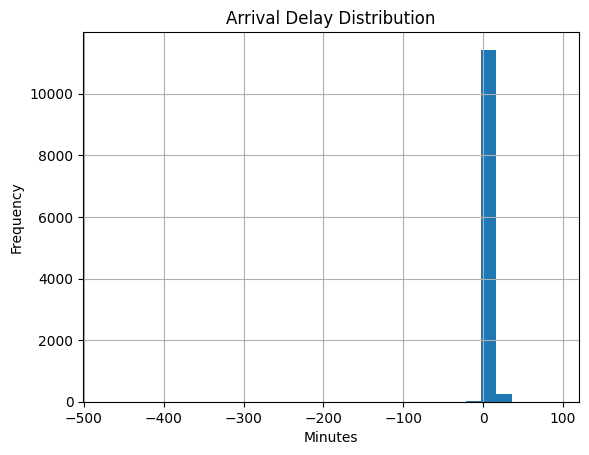

In [52]:
df["Average delay of all trains at arrival"].hist(bins=30)
plt.title("Arrival Delay Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

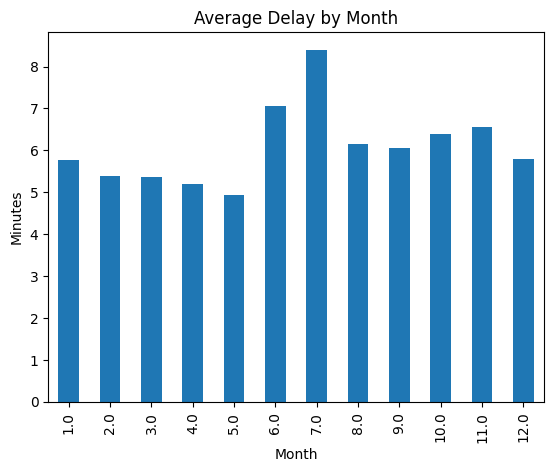

In [53]:
df.groupby("month")["Average delay of all trains at arrival"].mean().plot(kind="bar")
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Minutes")
plt.show()

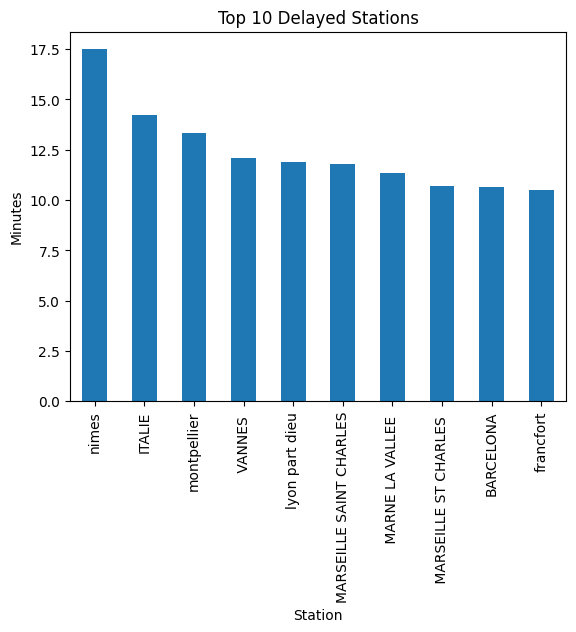

In [54]:
df.groupby("Departure station")["Average delay of all trains at arrival"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Delayed Stations")
plt.xlabel("Station")
plt.ylabel("Minutes")
plt.show()

## Insights

Most delays remain moderate.

Some stations are significantly more impacted.

Delay levels vary depending on the month.